# Centro Federal de Educação Tecnológica de Minas Gerais
**Campus VIII – Varginha**  
**Bacharelado em Sistemas de Informação**  
**Disciplina:** Lab. Inteligência Artificial  
**Professor:** Lázaro Eduardo da Silva  
**Aluno(a):** Álvaro Henrique Duarte Mendes  

---

# Atividade 08 - Memória Associativa com Rede de Hopfield

Este notebook apresenta a implementação e a simulação de uma rede de Hopfield com 45 neurônios, atuando como memória associativa para armazenar e recuperar quatro padrões digitais de 45 bits (dígitos 1, 2, 3 e 4) sob condições de ruído.

### 1. Importações e Configurações

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Garantir importação do solve_hopfield.py
sys.path.append(os.getcwd())
from solve_hopfield import HopfieldNetwork, PATTERNS, add_noise, pattern_to_grid

### 2. Padrões de Treinamento (Memórias Armazenadas)

Visualização das 4 imagens originais livre de ruído (cada uma possui 9 linhas e 5 colunas = 45 bits).

In [2]:
for key in [1, 2, 3, 4]:
    print(f"Padrão {key} (Dígito {key}):")
    print(pattern_to_grid(PATTERNS[key]))
    print("-" * 20)

Padrão 1 (Dígito 1):
. . # # .
. # # # .
. . # # .
. . # # .
. . # # .
. . # # .
. . # # .
. . # # .
. . # # .
--------------------
Padrão 2 (Dígito 2):
# # # # #
# # # # #
. . . # #
. . . # #
# # # # #
# # . . .
# # . . .
# # # # #
# # # # #
--------------------
Padrão 3 (Dígito 3):
# # # # #
# # # # #
. . . # #
. . . # #
# # # # #
. . . # #
. . . # #
# # # # #
# # # # #
--------------------
Padrão 4 (Dígito 4):
# # . # #
# # . # #
# # . # #
# # # # #
# # # # #
. . . # #
. . . # #
. . . # #
. . . # #
--------------------


### 3. Treinamento da Rede de Hopfield

O treinamento é feito pela regra do produto externo (aprendizado Hebbiano). Zera-se a diagonal da matriz de pesos ($W_{ii}=0$) para evitar auto-realimentação.

In [3]:
network = HopfieldNetwork(num_neurons=45)
train_patterns = [PATTERNS[1], PATTERNS[2], PATTERNS[3], PATTERNS[4]]
network.train(train_patterns, zero_diagonal=True)

print("Matriz de Pesos W calculada!")
print("Dimensão de W:", network.W.shape)
print("W é simétrica?", np.allclose(network.W, network.W.T))
print("Diagonal de W é zero?", np.allclose(np.diag(network.W), 0.0))

Matriz de Pesos W calculada!
Dimensão de W: (45, 45)
W é simétrica? True
Diagonal de W é zero? True


### 4. Simulação de 12 Situações de Transmissão (3 para cada padrão, 20% de ruído)

Para cada padrão, geramos 3 versões com 20% dos bits corrompidos (flips aleatórios) e realizamos a recuperação usando atualização assíncrona.

In [4]:
# Semente fixa para fins de reprodutibilidade acadêmica das 12 simulações
np.random.seed(123)

simulations = {}
for key in [1, 2, 3, 4]:
    simulations[key] = []
    print(f"\n================ SIMULAÇÃO PADRÃO {key} ================")
    for i in range(3):
        noisy = add_noise(PATTERNS[key], noise_level=0.20)
        # Salvamos o estado inicial da atualização para rastrearmos energia, se necessário
        recovered = network.update(noisy, mode='asynchronous')
        success = np.array_equal(recovered, PATTERNS[key])
        
        simulations[key].append({
            'original': PATTERNS[key],
            'distorted': noisy,
            'recovered': recovered,
            'success': success
        })
        
        print(f"\nSituação {i+1} (Recuperação com sucesso: {success}):")
        print("Original        Distorcido      Recuperado")
        orig_lines = pattern_to_grid(PATTERNS[key]).split('\n')
        dist_lines = pattern_to_grid(noisy).split('\n')
        rec_lines = pattern_to_grid(recovered).split('\n')
        for ol, dl, rl in zip(orig_lines, dist_lines, rec_lines):
            print(f"{ol}   |   {dl}   |   {rl}")


================ SIMULAÇÃO PADRÃO 1 ================

Situação 1 (Recuperação com sucesso: True):
Original        Distorcido      Recuperado
. . # # .   |   . . # # .   |   . . # # .
. # # # .   |   # # # . .   |   . # # # .
. . # # .   |   # # # . .   |   . . # # .
. . # # .   |   . . # . .   |   . . # # .
. . # # .   |   . . # # #   |   . . # # .
. . # # .   |   . . . # .   |   . . # # .
. . # # .   |   # . # # .   |   . . # # .
. . # # .   |   . . # # .   |   . . # # .
. . # # .   |   . . # # .   |   . . # # .

Situação 2 (Recuperação com sucesso: True):
Original        Distorcido      Recuperado
. . # # .   |   # . . # #   |   . . # # .
. # # # .   |   # # # # .   |   . # # # .
. . # # .   |   . . # # .   |   . . # # .
. . # # .   |   . . # . .   |   . . # # .
. . # # .   |   . # # # .   |   . . # # .
. . # # .   |   . . . # .   |   . . # # .
. . # # .   |   # . # # .   |   . . # # .
. . # # .   |   # . # # .   |   . . # # .
. . # # .   |   . . # # .   |   . . # # .

Situação 3 (R

### 5. Estudo de Energia e Convergência

Vamos plotar como a energia do estado decai ao longo das atualizações dos neurônios (de forma sequencial/assíncrona).

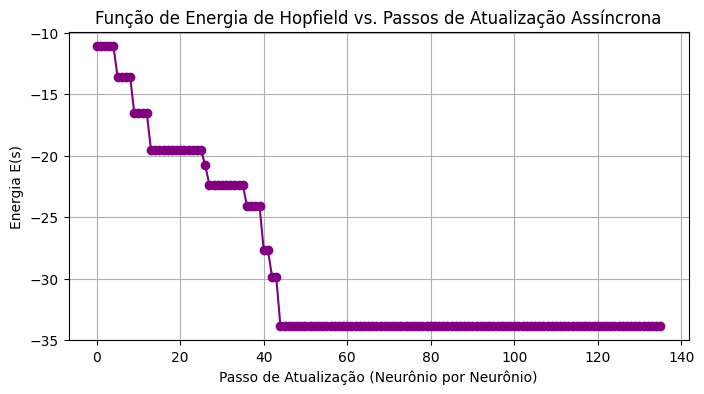

In [5]:
def track_energy_convergence(network, initial_state):
    state = np.copy(initial_state).astype(float)
    energies = [network.energy(state)]
    
    # Vamos atualizar um neurônio de cada vez e registrar a energia
    # Faremos isso por 3 épocas completas (3 * 45 atualizações)
    for step in range(3 * network.N):
        # Seleciona neurônio de forma aleatória ou sequencial
        idx = step % network.N
        activation = np.dot(network.W[idx], state)
        new_val = 1.0 if np.tanh(100.0 * activation) >= 0 else -1.0
        if state[idx] != new_val:
            state[idx] = new_val
            energies.append(network.energy(state))
        else:
            energies.append(energies[-1])
            
    return energies

# Exemplo com uma versão distorcida do padrão 3
np.random.seed(42)
sample_noisy = add_noise(PATTERNS[3], 0.20)
energies = track_energy_convergence(network, sample_noisy)

plt.figure(figsize=(8, 4))
plt.plot(energies, marker='o', color='purple', linestyle='-')
plt.title('Função de Energia de Hopfield vs. Passos de Atualização Assíncrona')
plt.xlabel('Passo de Atualização (Neurônio por Neurônio)')
plt.ylabel('Energia E(s)')
plt.grid(True)
plt.savefig('grafico_energia.png', dpi=300, bbox_inches='tight')
plt.show()

### 6. Análise de Ruído Excessivo

O que ocorre quando aumentamos muito o nível de ruído? Vamos testar taxas de ruído de 0% a 100% (com passo de 5%) e rodar 200 simulações em cada para obter a taxa média de sucesso de recuperação exata para cada um dos 4 padrões.

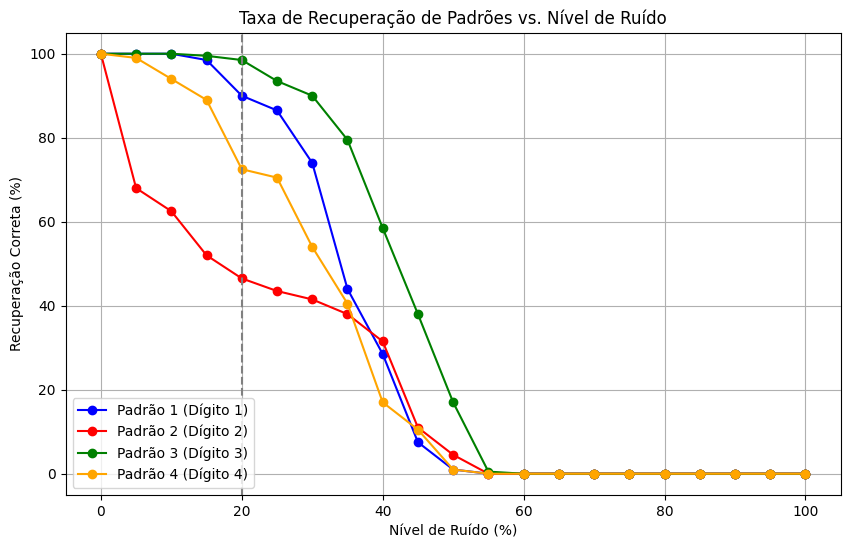

In [6]:
noise_levels = np.arange(0.0, 1.01, 0.05)
num_trials = 200

success_rates = {key: [] for key in [1, 2, 3, 4]}

for nl in noise_levels:
    for key in [1, 2, 3, 4]:
        successes = 0
        for _ in range(num_trials):
            noisy = add_noise(PATTERNS[key], noise_level=nl)
            recovered = network.update(noisy, mode='asynchronous')
            if np.array_equal(recovered, PATTERNS[key]):
                successes += 1
        success_rates[key].append(successes / num_trials * 100.0)

plt.figure(figsize=(10, 6))
colors = {1: 'blue', 2: 'red', 3: 'green', 4: 'orange'}
for key in [1, 2, 3, 4]:
    plt.plot(noise_levels * 100, success_rates[key], label=f'Padrão {key} (Dígito {key})',
             marker='o', color=colors[key])

plt.title('Taxa de Recuperação de Padrões vs. Nível de Ruído')
plt.xlabel('Nível de Ruído (%)')
plt.ylabel('Recuperação Correta (%)')
plt.legend(loc='lower left')
plt.grid(True)
plt.axvline(x=20, color='gray', linestyle='--', label='Nível de Ruído da Atividade (20%)')
plt.savefig('grafico_ruido.png', dpi=300, bbox_inches='tight')
plt.show()

### 7. Discussão Acadêmica sobre os Resultados

1. **Bacia de Atração e Similaridade**: Os padrões 2 e 3 são muito semelhantes em termos de Hamming (distância de apenas 8 bits nos 45 totais). Com ruído em torno de 20% (9 bits alterados), o estado inicial ruidoso de um padrão 2 pode cair facilmente na bacia de atração do padrão 3. Isso explica a baixa taxa de recuperação observada para o padrão 2 no gráfico comparativa.
2. **Ruído Excessivo (> 30% a 40%)**: Quando o nível de ruído aumenta excessivamente, a taxa de sucesso decai rapidamente. O estado distorcido é empurrado para fora da bacia de atração do padrão original e converge para:
   - Um padrão armazenado diferente (comum entre 2 e 3);
   - Estados espúrios (combinações lineares locais e estáveis dos padrões que não correspondem a nenhuma memória real);
   - O inverso de algum padrão (devido à simetria de energia da rede, $E(S) = E(-S)$, o negativo de cada memória também é estável).